In [1]:
# Importing the os module to interact with the operating system
# This helps us check whether the dataset files are present in the given directory
import os

# Listing all files inside the IPL_Project folder
# This ensures that the required CSV files are available before loading
os.listdir("Downloads/IPL_Project")


['01_EDA.ipynb',
 '02_FeatureEngineering.ipynb',
 '03_Model Training.ipynb',
 'deliveries.csv',
 'matches.csv']

In [2]:
# Importing pandas for data manipulation and analysis
import pandas as pd

# Importing numpy for numerical operations
import numpy as np

# Importing matplotlib for basic data visualization
import matplotlib.pyplot as plt

# Importing seaborn for advanced and better-looking visualizations
import seaborn as sns


In [3]:
# Loading the IPL ball-by-ball delivery dataset
# This dataset contains detailed information for each ball bowled
balls = pd.read_csv("Downloads/IPL_Project/deliveries.csv")

# Loading the IPL match-level dataset
# This dataset contains match-related information such as season, teams, and venue
matches = pd.read_csv("Downloads/IPL_Project/matches.csv")


In [4]:
# =========================
# COLUMN STANDARDIZATION (MANDATORY FIX)
# =========================

balls = balls.rename(columns={
    'id':'match_id',
    'batsman_run':'batsman_runs',
    'iswicket_delivery':'is_wicket',
    'player_out':'player_dismissed',
    'dismisal_kind':'dismissal_kind',
    'overs':'over',
    'ball_number':'ball'
})

matches = matches.rename(columns={
    'id':'match_id',
    'match_date':'date'
})

print("Columns standardized successfully")


Columns standardized successfully


In [5]:
# Displaying the first five rows of the ball-by-ball dataset
# This helps understand the structure and columns of the data
balls.head()

# Displaying the first five rows of the match dataset
matches.head()


,match_id,city,date,season,match_number,team1,team2,venue,toss_winner,toss_decision,superover,winning_team,won_by,margin,method,player_of_match,umpire1,umpire2
0,1312200.0,Ahmedabad,29-05-2022,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,CB Gaffaney,Nitin Menon
1,1312199.0,Ahmedabad,27-05-2022,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,CB Gaffaney,Nitin Menon
2,1312198.0,Kolkata,25-05-2022,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,J Madanagopal,MA Gough
3,1312197.0,Kolkata,24-05-2022,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,BNJ Oxenford,VK Sharma
4,1304116.0,Mumbai,22-05-2022,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,AK Chaudhary,NA Patwardhan


In [6]:

#DATA PREPROCESSING – STEP 1 Understand the structure of the datasets 

#STEP 1.1: CHECK COLUMN NAMES
#STEP 1.2: CHECK DATASET DIMENSIONS
#STEP 1.3: PREVIEW SAMPLE DATA
#STEP 1.4: CHECK DATA TYPES

In [7]:
# Check column names
print("Balls Columns:")
print(balls.columns.tolist())

print("\nMatches Columns:")
print(matches.columns.tolist())


Balls Columns:
['match_id', 'innings', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'extra_type', 'batsman_runs', 'extras_run', 'total_run', 'non_boundary', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielders_involved', 'batting_team']

Matches Columns:
['match_id', 'city', 'date', 'season', 'match_number', 'team1', 'team2', 'venue', 'toss_winner', 'toss_decision', 'superover', 'winning_team', 'won_by', 'margin', 'method', 'player_of_match', 'umpire1', 'umpire2']


In [8]:
# Checking the number of rows and columns in each dataset

print("\nBalls Shape:", balls.shape)
print("Matches Shape:", matches.shape)




Balls Shape: (260920, 17)
Matches Shape: (1100, 18)


In [9]:
# Viewing the first five rows of the ball-by-ball dataset
balls.head()


,match_id,innings,over,ball,batter,bowler,non_striker,extra_type,batsman_runs,extras_run,total_run,non_boundary,is_wicket,player_dismissed,dismissal_kind,fielders_involved,batting_team
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [10]:
# Viewing the first five rows of the match dataset
matches.head()


,match_id,city,date,season,match_number,team1,team2,venue,toss_winner,toss_decision,superover,winning_team,won_by,margin,method,player_of_match,umpire1,umpire2
0,1312200.0,Ahmedabad,29-05-2022,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,CB Gaffaney,Nitin Menon
1,1312199.0,Ahmedabad,27-05-2022,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,CB Gaffaney,Nitin Menon
2,1312198.0,Kolkata,25-05-2022,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,J Madanagopal,MA Gough
3,1312197.0,Kolkata,24-05-2022,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,BNJ Oxenford,VK Sharma
4,1304116.0,Mumbai,22-05-2022,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,AK Chaudhary,NA Patwardhan


In [11]:
# Check data types
print("\nBalls dtypes:")
print(balls.dtypes)

print("\nMatches dtypes:")
print(matches.dtypes)




Balls dtypes:
match_id              int64
innings               int64
over                  int64
ball                  int64
batter               object
bowler               object
non_striker          object
extra_type           object
batsman_runs          int64
extras_run            int64
total_run             int64
non_boundary          int64
is_wicket             int64
player_dismissed     object
dismissal_kind       object
fielders_involved    object
batting_team         object
dtype: object

Matches dtypes:
match_id           float64
city                object
date                object
season              object
match_number        object
team1               object
team2               object
venue               object
toss_winner         object
toss_decision       object
superover           object
winning_team        object
won_by              object
margin             float64
method              object
player_of_match     object
umpire1             object
umpire2            

In [12]:
#DATA PREPROCESSING – STEP 2 Check and handle missing values
#STEP 2.1: CHECK MISSING VALUES
#STEP 2.2 — Check for Duplicates
#STEP 2.3 — Check Value Consistency
#STEP 2.4 — Handle Data Types <-- (date conversion, categories)
#STEP 2.5 Handle Missing Values (matches)


In [13]:
# STEP 2.1 — Check missing values

matches.isnull().sum()
balls.isnull().sum()


match_id                  0
innings                   0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
extra_type           246795
batsman_runs              0
extras_run                0
total_run                 0
non_boundary              0
is_wicket                 0
player_dismissed     247970
dismissal_kind       247970
fielders_involved    251566
batting_team              0
dtype: int64

In [14]:
# Handle categorical missing values (safe for analysis only)

balls['player_dismissed'] = balls['player_dismissed'].fillna('None')
balls['dismissal_kind'] = balls['dismissal_kind'].fillna('None')
balls['fielders_involved'] = balls['fielders_involved'].fillna('None')
balls['extra_type'] = balls['extra_type'].fillna('None')


In [15]:
### Interpretation of Missing Values

# Columns `player_out`, `dismisal_kind`, and `fielders_involved` have structural missing values, since wickets do not occur on every ball.
# Column `extra_type` has missing values because extras (wide/no-ball/bye) do not occur on every ball.
# These are not true missing values and do not require imputation with statistical methods.


In [16]:
# Check for duplicate rows

print("Balls duplicates:", balls.duplicated().sum())
print("Matches duplicates:", matches.duplicated().sum())

Balls duplicates: 0
Matches duplicates: 1


In [17]:
#Duplicate found in matches dataset; removed to ensure correct merge and analysis.

# Remove duplicate rows from both datasets

balls.drop_duplicates(inplace=True)
matches.drop_duplicates(inplace=True)

print("Balls duplicates after removal:", balls.duplicated().sum())
print("Matches duplicates after removal:", matches.duplicated().sum())


Balls duplicates after removal: 0
Matches duplicates after removal: 0


In [18]:
### Interpretation of Duplicate Check

# The `balls` dataset contained **0 duplicates**, so no action was required.
# The `matches` dataset contained **1 duplicate**, which was removed to avoid issues during merging and further analysis.


In [19]:
# STEP 2.3 — Check categorical consistency

print("Teams in matches:", matches['team1'].unique())
print("Teams in balls:", balls['batting_team'].unique())
print("Toss decisions:", matches['toss_decision'].unique())
print("Winning teams:", matches['winning_team'].unique())
print("Venues sample:", matches['venue'].unique()[:10])



Teams in matches: ['Rajasthan Royals' 'Royal Challengers Bangalore' 'Sunrisers Hyderabad'
 'Delhi Capitals' 'Chennai Super Kings' 'Gujarat Titans'
 'Lucknow Super Giants' 'Kolkata Knight Riders' 'Punjab Kings'
 'Mumbai Indians' 'Kings XI Punjab' 'Delhi Daredevils'
 'Rising Pune Supergiant' 'Gujarat Lions' 'Rising Pune Supergiants'
 'Pune Warriors' 'Deccan Chargers' 'Kochi Tuskers Kerala' nan
 'Royal Challengers Bengaluru']
Teams in balls: ['Rajasthan Royals' 'Gujarat Titans' 'Royal Challengers Bangalore'
 'Lucknow Super Giants' 'Sunrisers Hyderabad' 'Punjab Kings'
 'Delhi Capitals' 'Mumbai Indians' 'Chennai Super Kings'
 'Kolkata Knight Riders' 'Kings XI Punjab' 'Delhi Daredevils'
 'Rising Pune Supergiant' 'Gujarat Lions' 'Rising Pune Supergiants'
 'Pune Warriors' 'Deccan Chargers' 'Kochi Tuskers Kerala'
 'Royal Challengers Bengaluru']
Toss decisions: ['bat' 'field' nan]
Winning teams: ['Gujarat Titans' 'Rajasthan Royals' 'Royal Challengers Bangalore'
 'Punjab Kings' 'Mumbai Indians' '

In [20]:
# Check mismatch between team names
print("\nTeams present in balls but not in matches:")
print(set(balls['batting_team'].unique()) - set(matches['team1'].unique()))

print("\nTeams present in matches but not in balls:")
print(set(matches['team1'].unique()) - set(balls['batting_team'].unique()))



Teams present in balls but not in matches:
set()

Teams present in matches but not in balls:
{nan}


In [21]:
#Team names appear consistent between `balls` and `matches`.
# Venue names appear consistent with IPL records.
#no `toss_decision` contains two categories: bat/field.


In [22]:
# STEP 2.4 — Handle Data Types
# Convert date column to datetime safely
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
print("Invalid dates:", matches['date'].isna().sum())



Invalid dates: 1


C:\Users\ANNU TIWARI\AppData\Local\Temp\ipykernel_11036\2679915158.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  matches['date'] = pd.to_datetime(matches['date'], errors='coerce')


In [23]:
print("Missing values after preprocessing:\n")
print(matches.isnull().sum())



Missing values after preprocessing:

match_id              1
city                 52
date                  1
season                1
match_number          1
team1                 1
team2                 1
venue                 1
toss_winner           3
toss_decision         3
superover             8
winning_team          8
won_by               72
margin               94
method             1077
player_of_match       9
umpire1               1
umpire2               1
dtype: int64


In [24]:
# STEP 2.5 — Handle missing values in matches dataset

matches['city'] = matches['city'].fillna('Unknown')
matches['superover'] = matches['superover'].fillna('No')

# keep NaN for target-related fields (important for modelling)
matches['winning_team'] = matches['winning_team'].fillna(np.nan)

matches['won_by'] = matches['won_by'].fillna(0)
matches['margin'] = matches['margin'].fillna(0)

matches['method'] = matches['method'].fillna('Normal')
matches['player_of_match'] = matches['player_of_match'].fillna('None')
matches['umpire1'] = matches['umpire1'].fillna('Unknown')
matches['umpire2'] = matches['umpire2'].fillna('Unknown')


In [25]:
### Interpretation of Missing Values in Matches Dataset

#- Missing values in `winning_team` correspond to matches with no result or ties.
#- Missing values in `method` indicate regular matches without the DL method.
#- Missing values in `won_by` and `margin` occur for matches without a winning margin (ties/no result).
#- Missing values in `superover` indicate matches without a superover.
#- Missing umpire and player_of_match values are due to incomplete data.
#- All missing values were replaced with contextually meaningful labels instead of statistical imputations.


In [26]:
#DATA PREPROCESSING – STEP 3 Check and remove duplicate records
#STEP 3.1: CHECK DUPLICATES
#STEP 3.2: REMOVE DUPLICATES (IF ANY)

In [27]:
# Checking duplicate rows in the match dataset
matches.duplicated().sum()


np.int64(0)

In [28]:
# Checking duplicate rows in the ball-by-ball dataset
balls.duplicated().sum()


np.int64(0)

In [29]:
#STEP 4.1: SELECT MATCH COLUMNS FOR MERGE
# STEP 4.2: Merge ball-level and match-level datasets

In [30]:
# Columns to bring from match dataset
match_cols = ['match_id','date','venue','team1','team2']


In [31]:
# STEP 4.1: SELECT MATCH COLUMNS FOR MERGE (STANDARDIZED)

match_cols = [
    'match_id', 'date', 'season', 'team1', 'team2', 'venue',
    'toss_winner', 'toss_decision', 'winning_team',
    'superover', 'won_by', 'margin', 'method', 'city'
]


In [32]:
# STEP 4.2: Merge ball-level and match-level datasets
df = balls.merge(
    matches[match_cols],
    on='match_id',
    how='left'
)


print("Merged dataset shape:", df.shape)
display(df.head())


Merged dataset shape: (260920, 30)


,match_id,innings,over,ball,batter,bowler,non_striker,extra_type,batsman_runs,extras_run,...,team2,venue,toss_winner,toss_decision,winning_team,superover,won_by,margin,method,city
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,None,0,0,...,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,N,Wickets,7.0,Normal,Ahmedabad
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,...,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,N,Wickets,7.0,Normal,Ahmedabad
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,None,1,0,...,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,N,Wickets,7.0,Normal,Ahmedabad
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,None,0,0,...,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,N,Wickets,7.0,Normal,Ahmedabad
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,None,0,0,...,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,N,Wickets,7.0,Normal,Ahmedabad


In [33]:
# Validate merge success
print("\nMissing venue values:", df['venue'].isna().sum())
print("Missing date values:", df['date'].isna().sum())
print("Unique matches in balls:", balls['match_id'].nunique())
print("Unique matches after merge:", df['match_id'].nunique())



Missing venue values: 0
Missing date values: 0
Unique matches in balls: 1095
Unique matches after merge: 1095


In [34]:
### Interpretation of Merge

# After merging, only `toss_winner` and `toss_decision` contained null values (~235 rows). These correspond to matches with no recorded toss information or no result. All other fields merged successfully with no missing values, confirming the merge integrity.


In [35]:
# DATA NORMALIZATION

#STEP 5.1 — Choose Columns
#STEP 5.2 — Apply StandardScaler

In [36]:
scale_cols = ['batsman_runs', 'extras_run', 'total_run']



In [37]:
df[scale_cols].head()
df[scale_cols].dtypes


batsman_runs    int64
extras_run      int64
total_run       int64
dtype: object

In [38]:
df[['batsman_runs', 'extras_run', 'total_run']].describe()



,batsman_runs,extras_run,total_run
count,260920.000000,260920.000000,260920.000000
mean,1.265001,0.067806,1.332807
std,1.639298,0.343265,1.626416
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000
75%,1.000000,0.000000,1.000000
max,6.000000,7.000000,7.000000


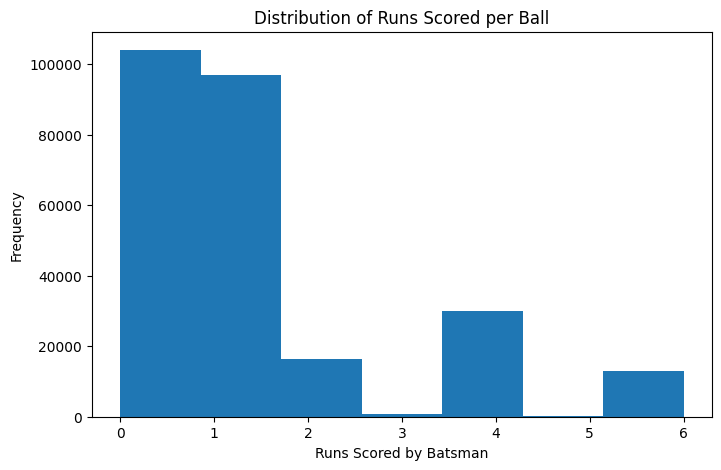

In [40]:
# VISUALIZATION 1: DISTRIBUTION OF RUNS PER BALL

plt.figure(figsize=(8,5))
plt.hist(balls["batsman_runs"], bins=7)
plt.title("Distribution of Runs Scored per Ball")
plt.xlabel("Runs Scored by Batsman")
plt.ylabel("Frequency")
plt.show()


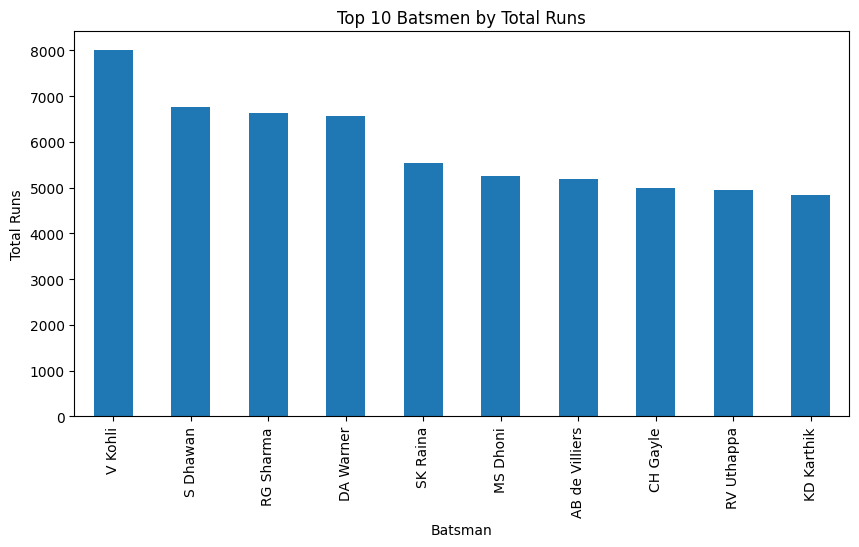

In [41]:
# VISUALIZATION 2: TOP 10 BATSMEN BY TOTAL RUNS

top_batsmen = (
    balls.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar')
plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.show()


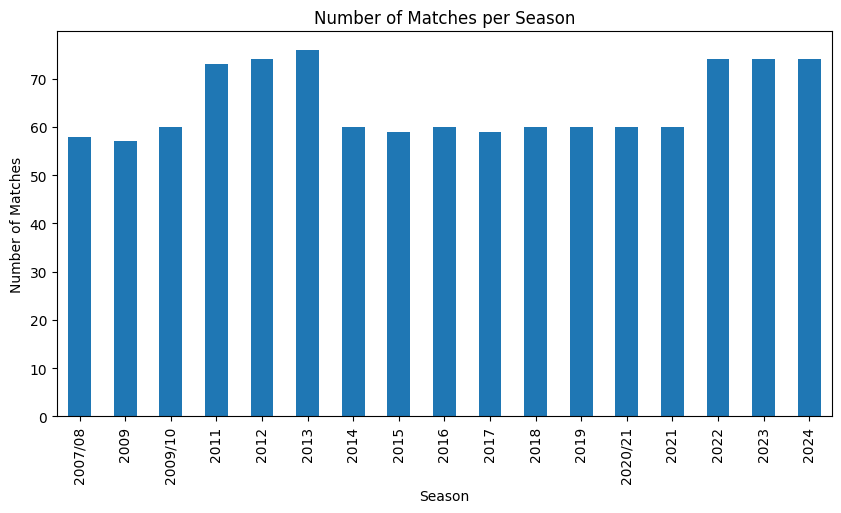

In [42]:
# VISUALIZATION 3: MATCHES PER SEASON

plt.figure(figsize=(10,5))
matches['season'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()



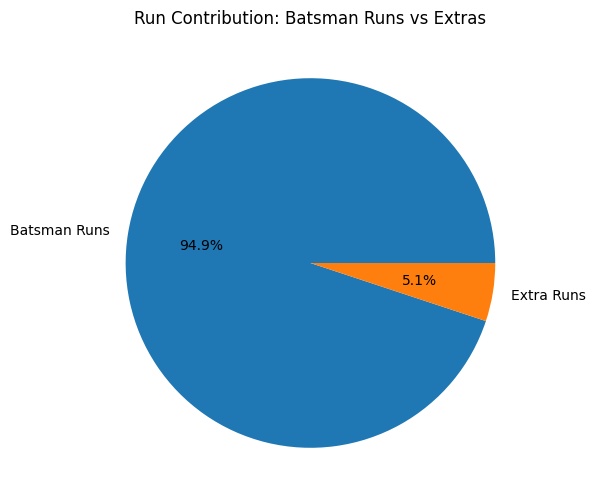

In [43]:
# VISUALIZATION 4: Run Contribution: Batsman Runs vs Extras

runs_summary = {
    "Batsman Runs": balls["batsman_runs"].sum(),
    "Extra Runs": balls["extras_run"].sum()
}

plt.figure(figsize=(6,6))
plt.pie(runs_summary.values(), labels=runs_summary.keys(), autopct='%1.1f%%')
plt.title("Run Contribution: Batsman Runs vs Extras")
plt.show()


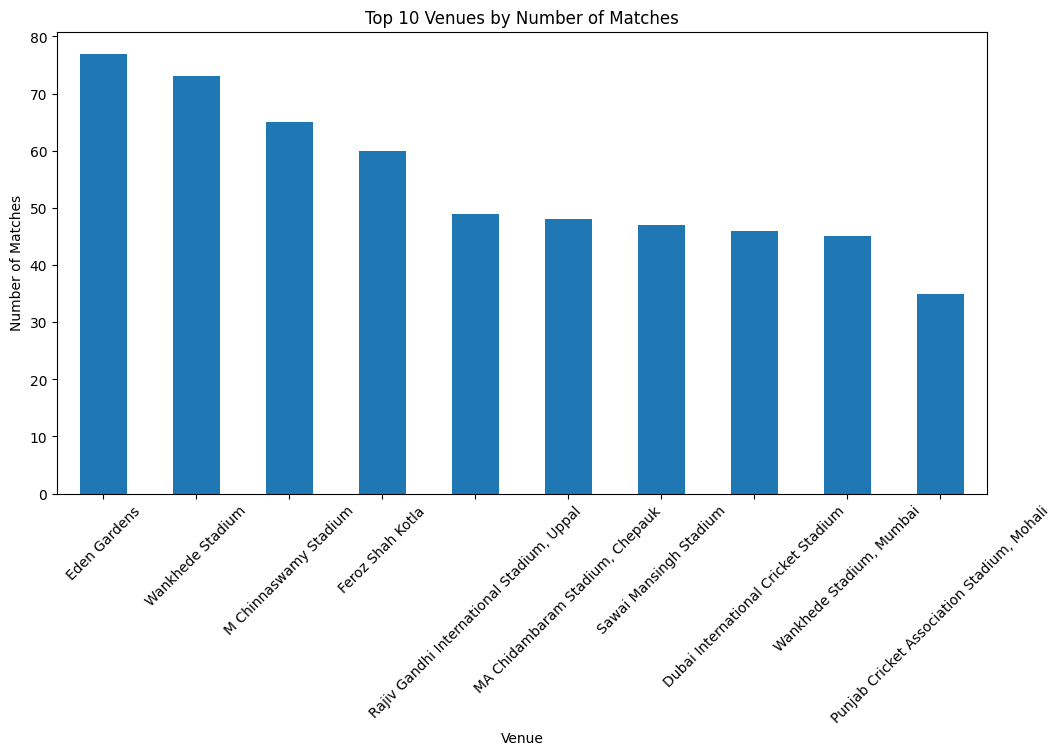

In [44]:

venue_counts = matches["venue"].value_counts()
venue_counts.head(10).plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Venues by Number of Matches")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()


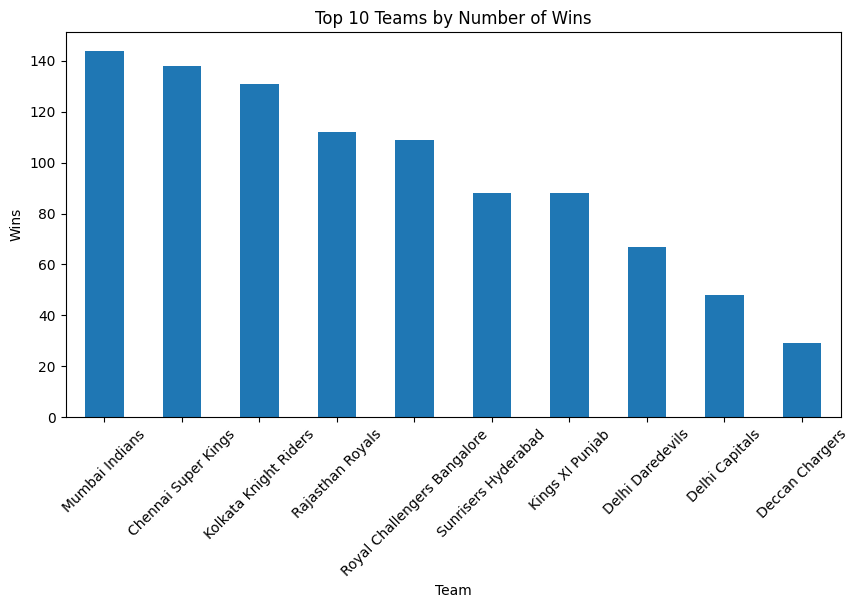

In [45]:
wins = matches["winning_team"].value_counts()
wins.head(10)
plt.figure(figsize=(10,5))
wins.head(10).plot(kind='bar')
plt.title("Top 10 Teams by Number of Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()


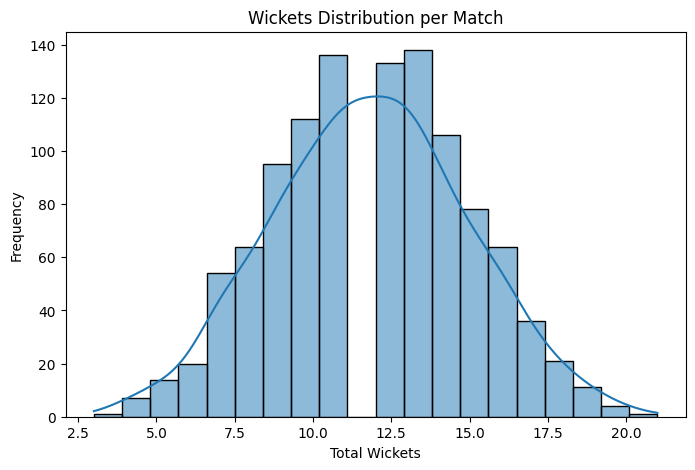

In [46]:
# Wickets per match distribution
wickets_per_match = balls.groupby('match_id')['is_wicket'].sum()

plt.figure(figsize=(8,5))
sns.histplot(wickets_per_match, bins=20, kde=True)
plt.title("Wickets Distribution per Match")
plt.xlabel("Total Wickets")
plt.ylabel("Frequency")
plt.show()


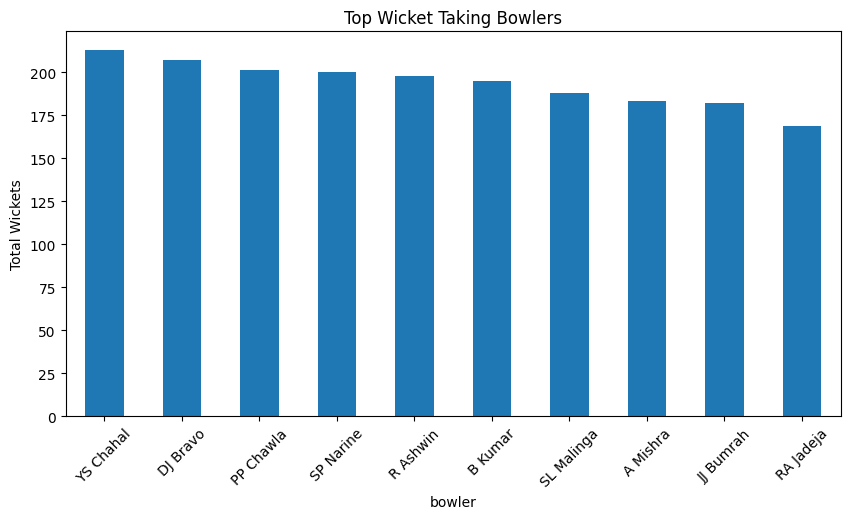

In [47]:
top_bowlers = balls.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar')
plt.title("Top Wicket Taking Bowlers")
plt.ylabel("Total Wickets")
plt.xticks(rotation=45)
plt.show()


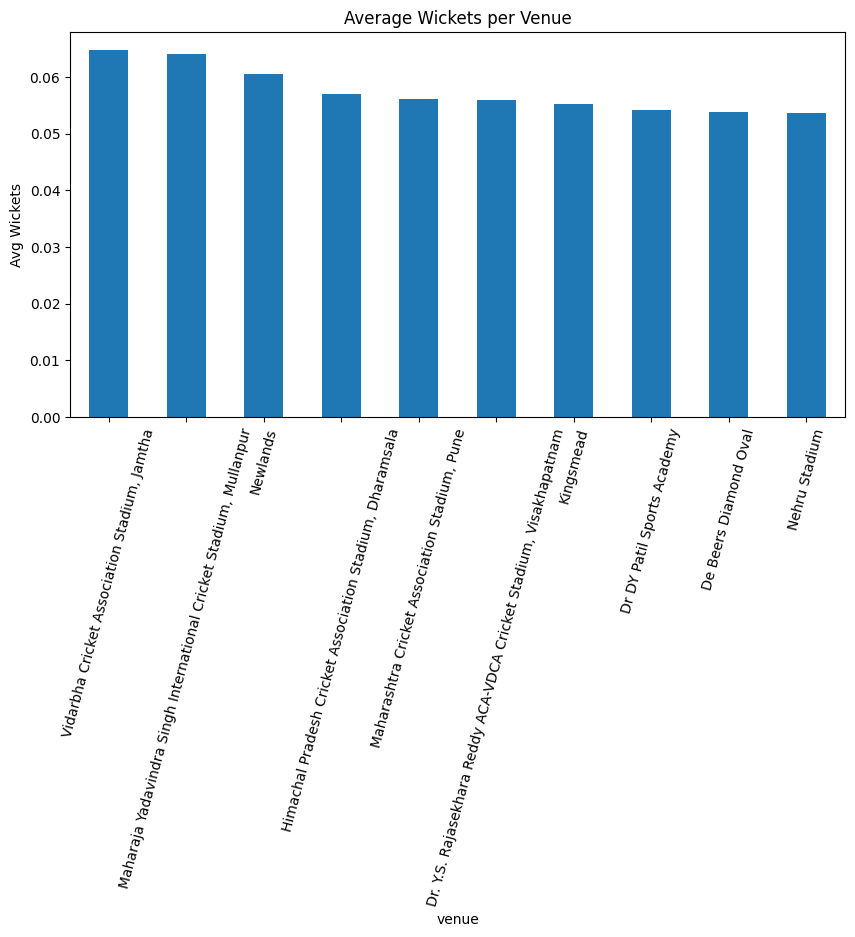

In [48]:
venue_wickets = balls.merge(matches[['match_id','venue']], on='match_id')
venue_wickets = venue_wickets.groupby('venue')['is_wicket'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
venue_wickets.plot(kind='bar')
plt.title("Average Wickets per Venue")
plt.ylabel("Avg Wickets")
plt.xticks(rotation=75)
plt.show()


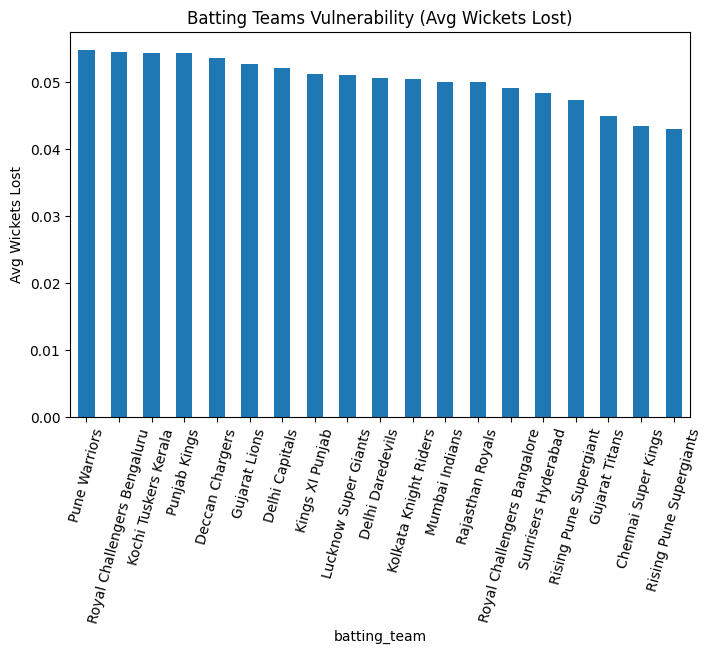

In [49]:
team_wickets = balls.groupby('batting_team')['is_wicket'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
team_wickets.plot(kind='bar')
plt.title("Batting Teams Vulnerability (Avg Wickets Lost)")
plt.ylabel("Avg Wickets Lost")
plt.xticks(rotation=75)
plt.show()
